In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize 0–1
x_train = x_train.astype("float32") / 255.
x_test  = x_test.astype("float32") / 255.

# Flatten 28x28 → 784
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

print(x_train.shape)  # (60000, 784)

(60000, 784)


In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * epsilon

In [ ]:
latent_dim = 2
original_dim = 784

encoder_inputs = keras.Input(shape=(original_dim,))
x = layers.Dense(128, activation="relu")(encoder_inputs)
x = layers.Dense(64, activation="relu")(x)

mu = layers.Dense(latent_dim, name="mu")(x)
log_var = layers.Dense(latent_dim, name="log_var")(x)

z = Sampling()([mu, log_var])

encoder = keras.Model(encoder_inputs, [mu, log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 784)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         100,480 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mu (Dense)                    │ (None, 2)                 │             130 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ log_var (Dense)               │ (None, 2)                 │             130 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sampling (Sampling)           │ (None, 2)                 │               0 │ mu[0][0], log_var[0][0]    │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 108,996 (425.77 KB)

 Trainable params: 108,996 (425.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(64, activation="relu")(latent_inputs)
x = layers.Dense(128, activation="relu")(x)
decoder_outputs = layers.Dense(original_dim, activation="sigmoid")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 2)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 784)                 │         101,136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,648 (428.31 KB)

 Trainable params: 109,648 (428.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        mu, log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        # Reconstruction loss
        # Reconstruction loss PER PIXEL
        reconstruction_loss = keras.backend.binary_crossentropy(inputs, reconstructed)
        reconstruction_loss = tf.reduce_sum(reconstruction_loss, axis=-1)

        # KL divergence
        kl_loss = -0.5 * tf.reduce_sum(
            1 + log_var - tf.square(mu) - tf.exp(log_var),
            axis=1
        )

        # Total VAE loss
        total_loss = tf.reduce_mean(reconstruction_loss + kl_loss)
        self.add_loss(total_loss)

        return reconstructed

In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

history = vae.fit(
    x_train, x_train,
    epochs=30,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 201.1785 - val_loss: 175.2617
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 171.2078 - val_loss: 168.3638
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 166.2864 - val_loss: 164.7453
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 162.9285 - val_loss: 161.4779
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 160.1249 - val_loss: 159.1168
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 157.7629 - val_loss: 156.7388
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 155.8786 - val_loss: 155.5101
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 154.3921 - val_loss: 153.8000
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 153.1175 - val_loss: 152.9029
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 152.0559 - val_loss: 151.7199
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 151.0156 - val_loss: 150.7625
Epoch 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


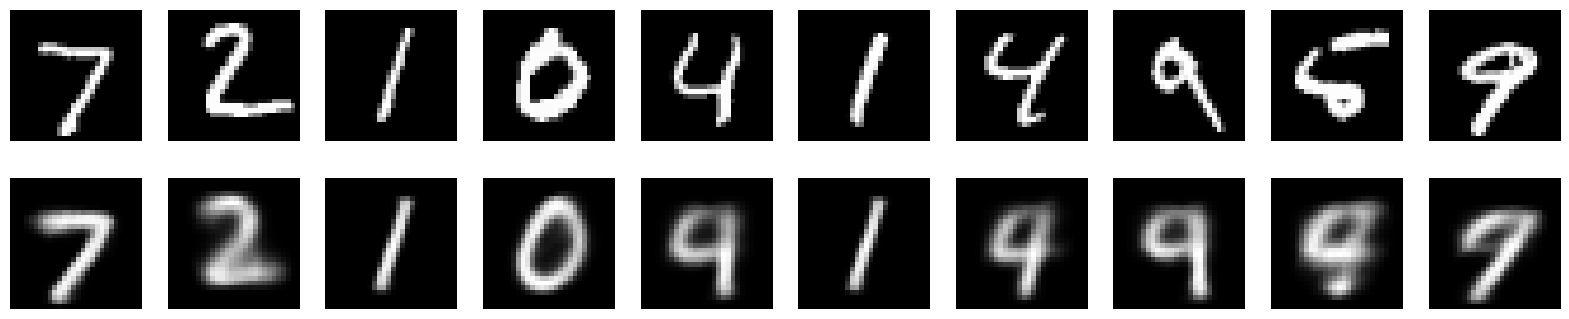

In [ ]:
n = 10
recon = vae.predict(x_test[:n])

plt.figure(figsize=(20,4))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    # reconstructed
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(recon[i].reshape(28,28), cmap="gray")
    plt.axis("off")
plt.show()